In [24]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

torch.manual_seed(42)

In [26]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

c:\Users\antag\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


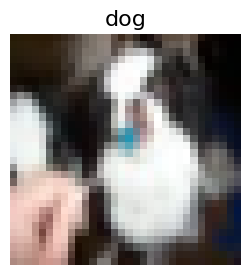

In [27]:
classes = train_dataset.classes

def show(img_tensor, lbl):
    img = img_tensor.permute(1, 2, 0)
    plt.figure(figsize=(3, 3))
    plt.title(classes[lbl], fontsize=16)
    plt.axis('off')
    plt.imshow(img)

rnd_idx = random.randint(0, len(train_dataset) - 1)
image, label = train_dataset[rnd_idx]
show(image, label)

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [29]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [30]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

In [31]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x, y = x.to(device), y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc


In [32]:
def plot_learning_curves(train_losses, test_losses):
  epochs = range(1, len(train_losses) + 1)
  plt.plot(epochs, train_losses, label="Train Loss")
  plt.plot(epochs, test_losses, label="Test Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Learning Curves")
  plt.legend()
  plt.show()

In [33]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3


Modelo 1

In [34]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  

    nn.Conv2d(50, 75, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, len(classes))
)

model_cnn = model_cnn.to(device)


In [35]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, test_loader, loss_function, optimizer, epochs)
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

Training: 100%|██████████| 20/20 [04:10<00:00, 12.53s/epoch, train_acc=0.8692, train_loss=0.3646, val_acc=0.7368, val_loss=0.8964]


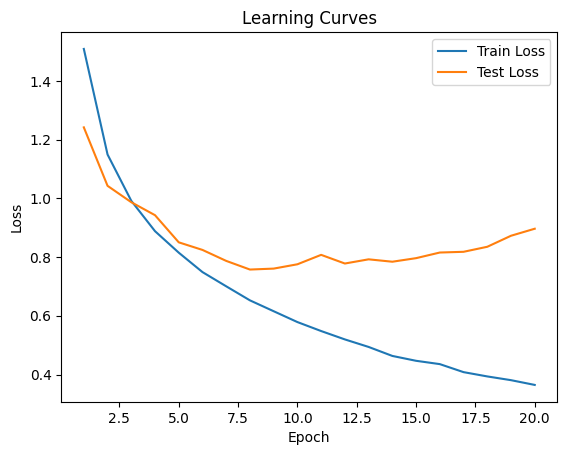

In [36]:
grafica_model_1 = plot_learning_curves(cnn_res['train_loss'], cnn_res['val_loss'])

Modelo 2

In [37]:
model2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),    
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, stride=1, padding=1),   
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                    
    nn.Dropout(.2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),   
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                    
    nn.Dropout(.3),

    nn.Conv2d(64, 128, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                    

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.Dropout(.4),
    nn.ReLU(),
    nn.Linear(512, len(classes))
)

model2 = model2.to(device)

In [38]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters())

cnn_res2 = train(model2, train_loader, test_loader, loss_function, optimizer, epochs)
cnn_test_loss, cnn_test_acc = test(model2, test_loader, loss_function)

Training: 100%|██████████| 20/20 [04:39<00:00, 13.97s/epoch, train_acc=0.7958, train_loss=0.5768, val_acc=0.7811, val_loss=0.6664]


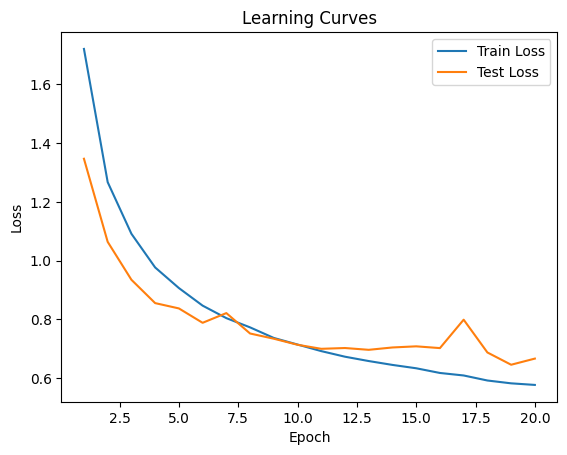

In [39]:
grafica_model_2 = plot_learning_curves(cnn_res2['train_loss'], cnn_res2['val_loss'])

Modelo 3

In [40]:
model3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Conv2d(32, 64, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.Dropout(.1),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(64, 128, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 1024),
    nn.Dropout(.2),
    nn.ReLU(),
    nn.Linear(1024, len(classes))
)

model3 = model3.to(device)

In [41]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters())

cnn_res3 = train(model3, train_loader, test_loader, loss_function, optimizer, epochs)
cnn_test_loss3, cnn_test_acc3 = test(model3, test_loader, loss_function)

Training: 100%|██████████| 20/20 [04:11<00:00, 12.57s/epoch, train_acc=0.9562, train_loss=0.1289, val_acc=0.7363, val_loss=1.3529]


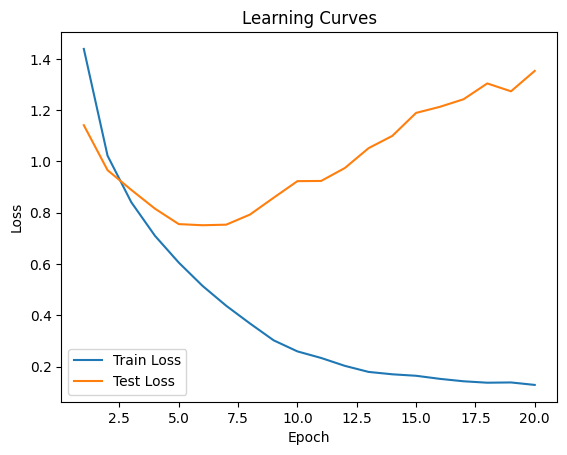

In [42]:
grafica_model_3 = plot_learning_curves(cnn_res3['train_loss'], cnn_res3['val_loss'])

In [43]:
m1_loss, m1_acc = test(model_cnn, test_loader, loss_function)
m2_loss, m2_acc = test(model2, test_loader, loss_function)
m3_loss, m3_acc = test(model3, test_loader, loss_function)

results = {
    "Modelo 1": {"loss": m1_loss, "accuracy": m1_acc},
    "Modelo 2": {"loss": m2_loss, "accuracy": m2_acc},
    "Modelo 3": {"loss": m3_loss, "accuracy": m3_acc},
}

print(f"{'Modelo':<12} {'Test Loss':>12} {'Test Accuracy':>15}")
print("-" * 42)
for name, metrics in results.items():
    print(f"{name:<12} {metrics['loss']:>12.4f} {metrics['accuracy']:>14.4f}")

best_model = max(results, key=lambda k: results[k]["accuracy"])
print(f"\nMejor modelo: {best_model} con accuracy = {results[best_model]['accuracy']:.4f}")


Modelo          Test Loss   Test Accuracy
------------------------------------------
Modelo 1           0.8964         0.7368
Modelo 2           0.6664         0.7811
Modelo 3           1.3529         0.7363

Mejor modelo: Modelo 2 con accuracy = 0.7811
